# Restaurant Recommendation

<img src='https://s3-alpha.figma.com/hub/file/5037974549/7b32e23f-bb2c-41c7-8938-e6ba32bdbb9b-cover.png'>

Bu çalışmada location, type, reviews gibi özellikler kullanılarak en popüler restaurantlar tespit edilecek ve restaurant öneri mekanizması geliştirilecektir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("TripAdvisor_RestauarantRecommendation.csv")

In [3]:
df.head()

,Name,Street Address,Location,Type,Reviews,No of Reviews,Comments,Contact Number,Trip_advisor Url,Menu,Price_Range
0,Betty Lou's Seafood and Grill,318 Columbus Ave,"San Francisco, CA 94133-3908","Seafood, Vegetarian Friendly, Vegan Options",4.5 of 5 bubbles,243 reviews,NaN,+1 415-757-0569,https://www.tripadvisor.com//Restaurant_Review...,Check The Website for a Menu,$$ - $$$
1,Coach House Diner,55 State Rt 4,"Hackensack, NJ 07601-6337","Diner, American, Vegetarian Friendly",4 of 5 bubbles,84 reviews,"Both times we were there very late, after 11 P...",+1 201-488-4999,https://www.tripadvisor.com//Restaurant_Review...,Check The Website for a Menu,$$ - $$$
2,Table Talk Diner,2521 South Rd Ste C,"Poughkeepsie, NY 12601-5476","American, Diner, Vegetarian Friendly",4 of 5 bubbles,256 reviews,Waitress was very friendly but a little pricey...,+1 845-849-2839,https://www.tripadvisor.com//Restaurant_Review...,http://tabletalkdiner.com/menu/breakfast/,$$ - $$$
3,Sixty Vines,3701 Dallas Pkwy,"Plano, TX 75093-7777","American, Wine Bar, Vegetarian Friendly",4.5 of 5 bubbles,235 reviews,Not sure why I went there for the second time....,+1 469-620-8463,https://www.tripadvisor.com//Restaurant_Review...,https://sixtyvines.com/menu/plano-tx/,$$ - $$$
4,The Clam Bar,3914 Brewerton Rd,"Syracuse, NY 13212","American, Bar, Seafood",4 of 5 bubbles,285 reviews,Doesn't look like much from the outside but wa...,+1 315-458-1662,https://www.tripadvisor.com//Restaurant_Review...,Check The Website for a Menu,$$ - $$$


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3062 entries, 0 to 3061
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Name              3062 non-null   object
 1   Street Address    3062 non-null   object
 2   Location          3062 non-null   object
 3   Type              3049 non-null   object
 4   Reviews           3062 non-null   object
 5   No of Reviews     3062 non-null   object
 6   Comments          2447 non-null   object
 7   Contact Number    3062 non-null   object
 8   Trip_advisor Url  3062 non-null   object
 9   Menu              3062 non-null   object
 10  Price_Range       3062 non-null   object
dtypes: object(11)
memory usage: 263.3+ KB


In [5]:
df.isnull().sum()

Name                  0
Street Address        0
Location              0
Type                 13
Reviews               0
No of Reviews         0
Comments            615
Contact Number        0
Trip_advisor Url      0
Menu                  0
Price_Range           0
dtype: int64

In [6]:
df.shape

(3062, 11)

In [7]:
# Eksik değerleri silelim
df = df.dropna(axis=1, how='all')

In [8]:
df.head()

,Name,Street Address,Location,Type,Reviews,No of Reviews,Comments,Contact Number,Trip_advisor Url,Menu,Price_Range
0,Betty Lou's Seafood and Grill,318 Columbus Ave,"San Francisco, CA 94133-3908","Seafood, Vegetarian Friendly, Vegan Options",4.5 of 5 bubbles,243 reviews,NaN,+1 415-757-0569,https://www.tripadvisor.com//Restaurant_Review...,Check The Website for a Menu,$$ - $$$
1,Coach House Diner,55 State Rt 4,"Hackensack, NJ 07601-6337","Diner, American, Vegetarian Friendly",4 of 5 bubbles,84 reviews,"Both times we were there very late, after 11 P...",+1 201-488-4999,https://www.tripadvisor.com//Restaurant_Review...,Check The Website for a Menu,$$ - $$$
2,Table Talk Diner,2521 South Rd Ste C,"Poughkeepsie, NY 12601-5476","American, Diner, Vegetarian Friendly",4 of 5 bubbles,256 reviews,Waitress was very friendly but a little pricey...,+1 845-849-2839,https://www.tripadvisor.com//Restaurant_Review...,http://tabletalkdiner.com/menu/breakfast/,$$ - $$$
3,Sixty Vines,3701 Dallas Pkwy,"Plano, TX 75093-7777","American, Wine Bar, Vegetarian Friendly",4.5 of 5 bubbles,235 reviews,Not sure why I went there for the second time....,+1 469-620-8463,https://www.tripadvisor.com//Restaurant_Review...,https://sixtyvines.com/menu/plano-tx/,$$ - $$$
4,The Clam Bar,3914 Brewerton Rd,"Syracuse, NY 13212","American, Bar, Seafood",4 of 5 bubbles,285 reviews,Doesn't look like much from the outside but wa...,+1 315-458-1662,https://www.tripadvisor.com//Restaurant_Review...,Check The Website for a Menu,$$ - $$$


In [9]:
# Reviews sütununu sayıya dönüştürelim -of 5 bubles'ları kaldıralım
df['Rating'] = df['Reviews'].str.extract('(\d+\.?\d*)').astype(float)

In [10]:
df['No of Reviews'].value_counts()

No of Reviews
58 reviews       18
36 reviews       16
106 reviews      16
53 reviews       15
35 reviews       15
                 ..
1,201 reviews     1
748 reviews       1
536 reviews       1
4,620 reviews     1
858 reviews       1
Name: count, Length: 811, dtype: int64

In [13]:
# No of Reviews sütununu sayıya dönüştürelim - reviews silelim
df['Review_Count'] = pd.to_numeric(
    df['No of Reviews'].str.replace(' reviews', '').str.replace(' review', '').str.replace(',', '').str.strip(),
    errors='coerce'
).fillna(0).astype(int)

In [14]:
df['Review_Count'].value_counts()

Review_Count
58      18
36      16
106     16
53      15
35      15
        ..
1201     1
748      1
536      1
4620     1
858      1
Name: count, Length: 811, dtype: int64

In [15]:
# restaurant analizi, en polüler resaturantlar
restoran_istatistik = df.groupby('Name').agg({
    'Rating': 'first',
    'Review_Count': 'first',
    'Type': 'first',
    'Location': 'first'
})

In [16]:
# Review sayısına göre sıralayalım
populer_restoranlar = restoran_istatistik.sort_values(by='Review_Count', ascending=False)

In [17]:
populer_restoranlar

,Rating,Review_Count,Type,Location
Name,,,,
Big Texan Steak Ranch,4.0,5448,"American, Steakhouse, Southwestern","Amarillo, TX 79118-6915"
Boudro's,4.5,4620,"American, Southwestern, Vegetarian Friendly","San Antonio, TX 78205-2814"
The River Cafe,4.5,4055,"American, Wine Bar, Vegetarian Friendly","Brooklyn, NY 11201-1335"
Club A Steakhouse,4.5,3978,"American, Steakhouse, Gluten Free Options","New York City, NY 10022-2001"
Taste of Texas Restaurant,4.5,3807,"American, Steakhouse, Vegetarian Friendly","Houston, TX 77024-1001"
...,...,...,...,...
Currant Bistro,4.0,7,"American, Mediterranean, European","Seattle, WA 98121-2308"
Henry's Ocean View Dining,5.0,7,"Steakhouse, Seafood","Huntington Beach, CA 92648"
Ammatoli Mediterranean Bites,4.0,5,"Lebanese, Mediterranean, Middle Eastern","Long Beach, CA 90802-3141"


In [18]:
# YÜZDE HESAPLAYALIM
toplam_review = populer_restoranlar['Review_Count'].sum()
populer_restoranlar['yuzde'] = (populer_restoranlar['Review_Count'] / toplam_review) * 100
populer_restoranlar['siralama'] = populer_restoranlar['yuzde'].rank(ascending=False)

In [19]:
populer_restoranlar[['Review_Count', 'yuzde', 'siralama']].head(15)

,Review_Count,yuzde,siralama
Name,,,
Big Texan Steak Ranch,5448,0.699712,1.0
Boudro's,4620,0.593368,2.0
The River Cafe,4055,0.520803,3.0
Club A Steakhouse,3978,0.510913,4.0
Taste of Texas Restaurant,3807,0.488951,5.0
Trio Restaurant,3785,0.486125,6.0
Hollywood Cafe,3775,0.484841,7.0
Le Bernardin,3444,0.442329,8.0
Daniel,3274,0.420495,9.0


In [20]:
# TAVSİYE EDİLEN RESTORANLAR
tavsiye_restoranlar = populer_restoranlar.sort_values(by='siralama', ascending=True)[['Rating', 'Review_Count', 'Type', 'yuzde', 'siralama']].head(15)

In [21]:
tavsiye_restoranlar

,Rating,Review_Count,Type,yuzde,siralama
Name,,,,,
Big Texan Steak Ranch,4.0,5448,"American, Steakhouse, Southwestern",0.699712,1.0
Boudro's,4.5,4620,"American, Southwestern, Vegetarian Friendly",0.593368,2.0
The River Cafe,4.5,4055,"American, Wine Bar, Vegetarian Friendly",0.520803,3.0
Club A Steakhouse,4.5,3978,"American, Steakhouse, Gluten Free Options",0.510913,4.0
Taste of Texas Restaurant,4.5,3807,"American, Steakhouse, Vegetarian Friendly",0.488951,5.0
Trio Restaurant,4.5,3785,"American, Bar, Contemporary",0.486125,6.0
Hollywood Cafe,4.5,3775,"American, Cafe, Vegetarian Friendly",0.484841,7.0
Le Bernardin,4.5,3444,"French, Vegetarian Friendly, Gluten Free Options",0.442329,8.0
Daniel,4.5,3274,"French, Vegetarian Friendly, Vegan Options",0.420495,9.0


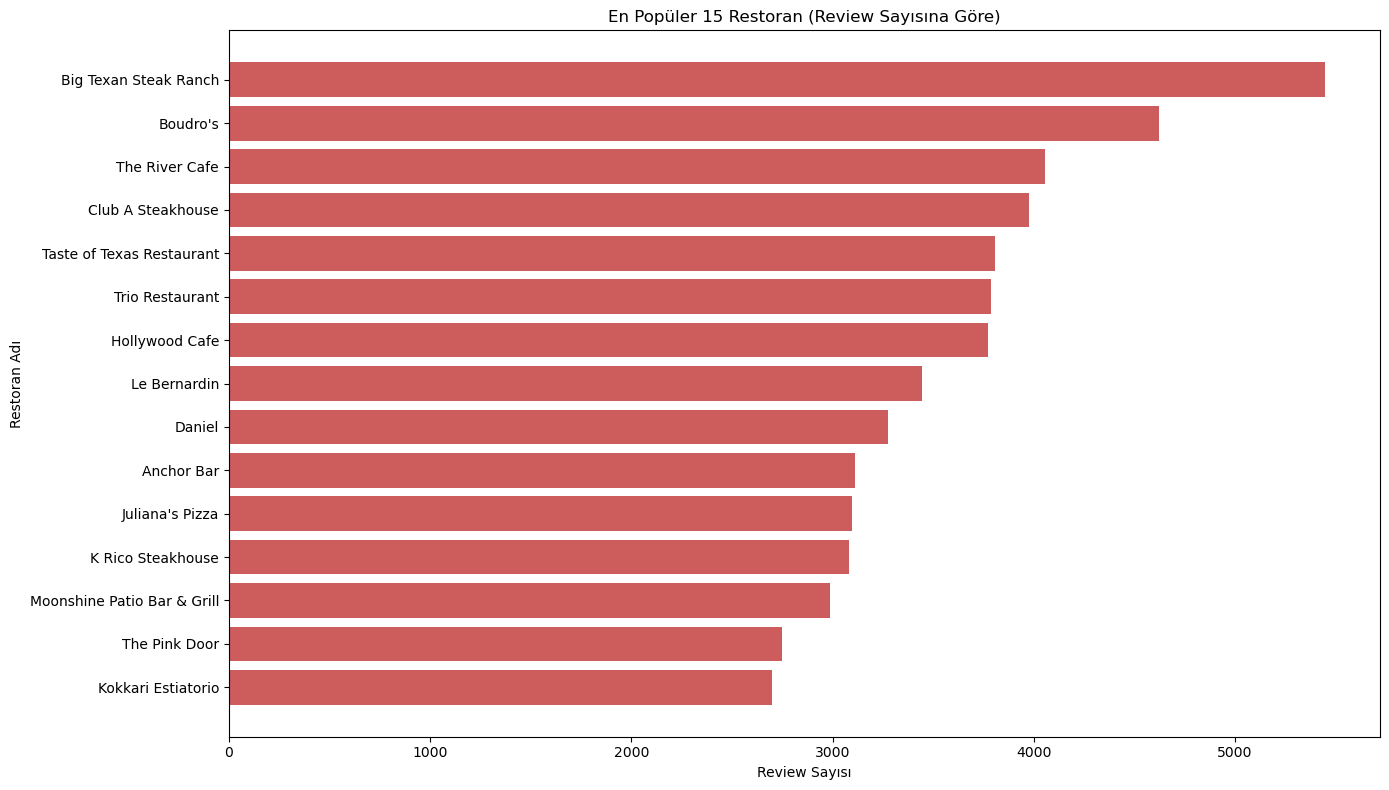

In [22]:
# En popüler restoranlar
plt.figure(figsize=(14, 8))
data = populer_restoranlar.head(15).sort_values(by='Review_Count', ascending=True)
plt.barh(range(len(data)), data['Review_Count'], color='#CD5C5C')
plt.yticks(range(len(data)), data.index, fontsize=10)
plt.xlabel('Review Sayısı')
plt.ylabel('Restoran Adı')
plt.title('En Popüler 15 Restoran (Review Sayısına Göre)')
plt.tight_layout()
plt.show()

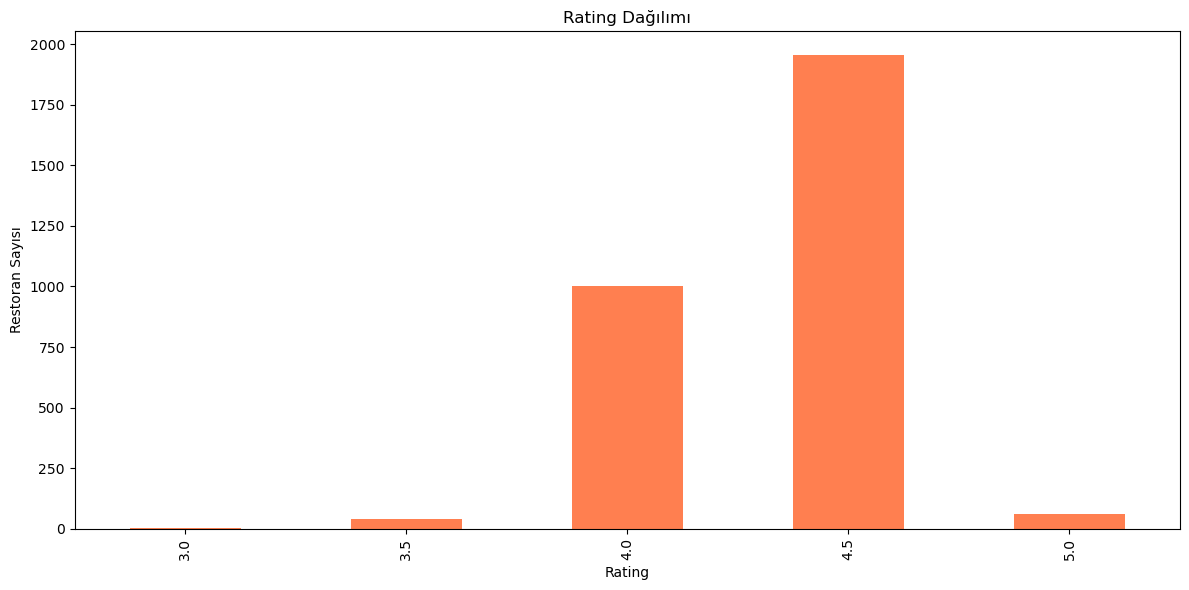

In [23]:
# Rating
plt.figure(figsize=(12, 6))
df['Rating'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.xlabel('Rating')
plt.ylabel('Restoran Sayısı')
plt.title('Rating Dağılımı')
plt.tight_layout()
plt.show()

Bu çalışmada restoranların popülarite, rating, türü ve konumu analiz ederek en uygun restoran önerileri geliştirilmiştir.